# Bepaling van soortelijke warmte van water


# Introductie

Water heeft een enorme buffercapaciteit: je moet veel energie toevoegen om de temperatuur van water een graad te verwarmen. In dit practicum gaan we de soortelijke warmte van water bepalen door een bekende hoeveelheid water te verwarmen met een bekende hoeveelheid energie, en de temperatuurstijging te meten.

# Theorie


Water heeft een hoge soortelijke warmte ($c$), wat betekent dat het veel energie kan opnemen
vooraleer de temperatuur merkbaar stijgt. De soortelijke warmte wordt gedefinieerd als de 
hoeveelheid warmte-energie ($Q$) die nodig is om de temperatuur van 1 kilogram van een stof 
met 1 graad Celsius te verhogen:

$c = Q/(m \Delta T)$

waarbij:
    $c$       = soortelijke warmte (J/(kg·°C))
    $Q$       = toegevoegde warmte (J)
    $m$       = massa van de stof (kg)
    $\Delta T$ = temperatuurstijging (°C)

In dit practicum wordt een bekende hoeveelheid water verwarmd door een bekende hoeveelheid 
energie toe te voegen, en wordt de resulterende temperatuurstijging gemeten. Zo kan met 
de formule $c = \frac{Q}{m \Delta T}$ de soortelijke warmte van water worden bepaald.

Water wordt vaak gebruikt als thermisch bufferend medium vanwege zijn hoge soortelijke warmte,
waardoor het langzaam opwarmt en afkoelt en temperatuurveranderingen dempt.



# Methode en materialen

## Ontwerp
Een waterbad met bekende massa aan water wordt verwarmd met een elektrisch verwarmingselement dat een bekende hoeveelheid energie levert.
De temperatuur van het water wordt gemeten met een temperatuursensor.
Door de temperatuurstijging als functie van de tijd te meten kan de soortelijke warmte van water worden berekend.


## Materialen
Hieronder staat de lijst van benodigde materialen bij deze proef:
- Maatbeker
- Weegschaal
- Water
- Elektrisch verwarmingselement ($10 \mathrm{\Omega}$, $10 \mathrm{W}$)
- Voedingsbron 
- Thermometer of temperatuursensor
- Stopwatch of timer

```{figure} figures/cwater_setup.jpg
:width: 70%

Een schematische weergave van de opstelling
```

## Procedure
1. Voorbereiding
- Meet een bekende hoeveelheid water af en bepaal de massa (m).
- Giet het water in het waterbad.

2. Opstelling
- Plaats het elektrische verwarmingselement in het water en sluit het aan op de voedingsbron.
- Plaats de thermometer of temperatuursensor in het water.

3. Verwarmen en meten
- Start de timer bij inschakelen van het element.
- Meet regelmatig de temperatuur van het water (T) gedurende de verwarming.

4. Data en berekening
- Bereken de toegevoegde energie: Q = P * t
- Bepaal de temperatuurstijging: ΔT = T_eind - T_begin
- Bereken de soortelijke warmte: c = Q / (m * ΔT)

5. Afronden
- Schakel het element uit, verwijder het uit het water, en ruim materialen op.
- Noteer eventuele observaties of afwijkingen.


## Veiligheid
We maken gebruik van een $10 \mathrm{\Omega}$, $10 \mathrm{W}$ weerstand.
Deze wordt snel heet.
De bronspanning mag dan ook alleen aan wanneer de weerstand in het water zit.
Raak de weerstand niet aan tijdens het experiment.
Omdat de weerstand in het water zit, kunnen we wel het elektrisch vermogen hoger zetten zonder dat de weerstand oververhit raakt.
Het maximaal vermogen mag $40 \mathrm{W}$ zijn.
Daarbij moet de roerder wel aanstaan om de warmte goed te verdelen.

## Data analyse
- Noteer de gemeten temperaturen als functie van de tijd.
- Bepaal de totale temperatuurstijging ΔT = T_eind - T_begin.
- Bereken de toegevoegde energie: Q = P * t.
- Bereken de soortelijke warmte van water: c = Q / (m * ΔT).
- Vergelijk de berekende waarde met de bekende literatuurwaarde van c.

# Resultaten


Vermogen P = 41.20 W
Helling dT/dt (eerste 240 s) = 0.0240 °C/s
Soortelijke warmte c = 4284 J/(kg·°C)
Onzekerheid Δc ≈ ±54 J/(kg·°C)
Soortelijke warmte inclusief onzekerheid: c = 4284 ± 54 J/(kg·°C)
Literatuurwaarde water: c_lit = 4180 J/(kg·°C)
Verschil gemeten vs literatuur: 104 J/(kg·°C)


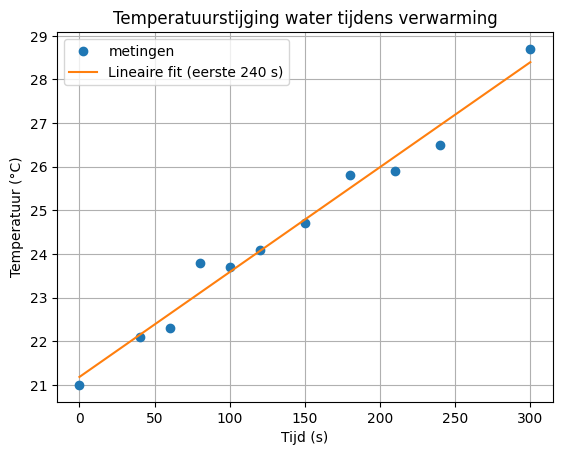

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# Gegevens
M_water = 0.400  # kg
tijd = np.array([0, 40, 60, 80, 100, 120, 150, 180, 210, 240, 300])  # s
temperatuur = np.array([21.0, 22.1, 22.3, 23.8, 23.7, 24.1, 24.7, 25.8, 25.9, 26.5, 28.7])  # °C
V = 20  # Volt
I = 2.06  # Ampere

# Bereken vermogen
P = V * I  # Watt
print(f"Vermogen P = {P:.2f} W")


# Lineaire fit
coeffs = np.polyfit(tijd, temperatuur, 1)
slope, intercept = coeffs
print(f"Helling dT/dt (eerste 240 s) = {slope:.4f} °C/s")

# Bereken soortelijke warmte
c = P / (M_water * slope)
print(f"Soortelijke warmte c = {c:.0f} J/(kg·°C)")

# Onzekerheidsanalyse (kwadratisch optellen)
rel_unc_P = 0.001  # ±5% vermogen
rel_unc_m = 0.005 / M_water  # ±0,005 kg
rel_unc_slope = 0.001  # ±5% helling

rel_unc_c = np.sqrt(rel_unc_P**2 + rel_unc_m**2 + rel_unc_slope**2)
delta_c = rel_unc_c * c
print(f"Onzekerheid Δc ≈ ±{delta_c:.0f} J/(kg·°C)")
print(f"Soortelijke warmte inclusief onzekerheid: c = {c:.0f} ± {delta_c:.0f} J/(kg·°C)")

# Vergelijking met literatuurwaarde
c_lit = 4180  # J/(kg·°C)
print(f"Literatuurwaarde water: c_lit = {c_lit} J/(kg·°C)")
verschil = c - c_lit
print(f"Verschil gemeten vs literatuur: {verschil:.0f} J/(kg·°C)")

# Plot
t_fit_plot = np.linspace(0, 300, 100)
T_fit_plot = slope * t_fit_plot + intercept

plt.plot(tijd, temperatuur, 'o', label="metingen")
plt.plot(t_fit_plot, T_fit_plot, '-', label=f"Lineaire fit (eerste 240 s)")
plt.xlabel("Tijd (s)")
plt.ylabel("Temperatuur (°C)")
plt.title("Temperatuurstijging water tijdens verwarming")
plt.legend()
plt.grid(True)
plt.show()




# Discussie en conclusie

Hier een korte discussie en conclusie over de resultaten van het experiment en de implicaties daarvan.

De berekende soortelijke warmte van water is 
𝑐
≈
5065
 
J
/
(
k
g
⋅
°
C
)
c≈5065 J/(kg⋅°C), wat hoger ligt dan de literatuurwaarde. Dit verschil kan verklaard worden door warmteverlies aan de omgeving en meetonnauwkeurigheden.